In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

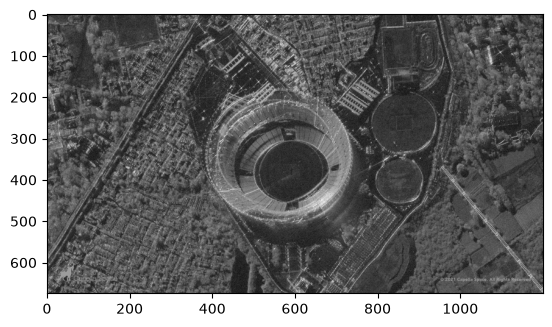

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")

In [3]:
# Зашумить изображение при помощи шума гаусса

In [4]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  16,   0, ..., 111,   0,  80],
       [  1, 104,  68, ...,   0, 103,   0],
       [  0,   0,  51, ...,   0,   0, 145],
       ...,
       [  0,   0,  39, ..., 255,   0,  15],
       [  0,  34,   0, ...,   0,   5, 135],
       [160, 204,   0, ...,  21,   0, 109]],
      shape=(675, 1200), dtype=uint8)

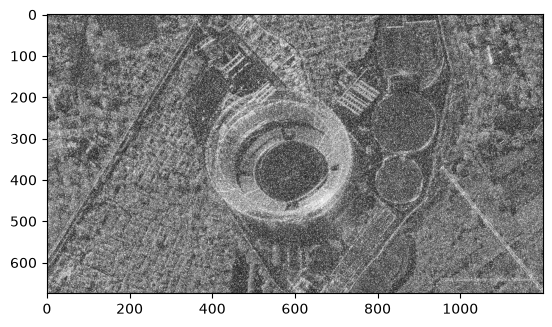

In [5]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

In [6]:
# Зашумить изображение при помощи постоянного шума

In [7]:
noise_const = np.random.uniform(-50, 50, image_gray.shape).astype(np.uint8)
cv2.randn(noise_const, mean, stddev)

array([[  0,  84,  79, ...,   0, 255, 130],
       [ 62,  27,  22, ..., 105,   6, 111],
       [ 28,   0,  57, ..., 127, 145,   0],
       ...,
       [  0,   0, 136, ...,  51, 116, 133],
       [ 43,  17,  32, ...,  45,   0,  81],
       [143, 159,   0, ...,  25,   0, 169]],
      shape=(675, 1200), dtype=uint8)

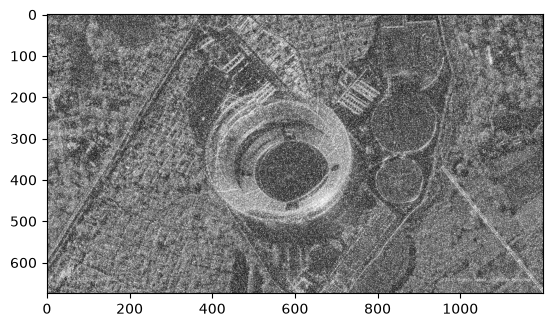

In [8]:
image_noise_const = cv2.add(image_gray, noise_const)
plt.imshow(image_noise_const, cmap="gray")

In [9]:
# Протестировать медианный фильтр

In [10]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print("Для изображения с шумом гауса: mse - ", mse_gauss, ", ssim - ", ssim_gauss)

mse_const = mean_squared_error(image_gray, image_noise_const)
(ssim_const, diff) = structural_similarity(image_gray,  image_noise_const, full=True)
print("Для изображения с постоянным шумом: mse - ", mse_const, ", ssim - ", ssim_const)

Для изображения с шумом гауса: mse -  4230.673058024691 , ssim -  0.18699266800035377
Для изображения с постоянным шумом: mse -  4226.025272839506 , ssim -  0.18728917567733988


In [11]:
image_gauss_median1 = cv2.medianBlur(image_noise_gauss, 3)
image_gauss_median2 = cv2.medianBlur(image_noise_gauss, 5)
image_gauss_median3 = cv2.medianBlur(image_noise_gauss, 9)

image_const_median1 = cv2.medianBlur(image_noise_const, 3)
image_const_median2 = cv2.medianBlur(image_noise_const, 5)
image_const_median3 = cv2.medianBlur(image_noise_const, 9)

In [12]:
#plt.imshow(image_gauss_median1, cmap="gray")

In [13]:
#plt.imshow(image_const_median1, cmap="gray")

In [14]:
mse_gauss_median1 = mean_squared_error(image_gray, image_gauss_median1)
(ssim_gauss_median1, diff) = structural_similarity(image_gray,  image_gauss_median1, full=True)
print("Для изображения с шумом гаусса с медианным фильтром (параметр 3): mse - ", mse_gauss_median1, ", ssim - ", ssim_gauss_median1)

mse_const_median1 = mean_squared_error(image_gray, image_const_median1)
(ssim_const_median1, diff) = structural_similarity(image_gray,  image_const_median1, full=True)
print("Для изображения с постоянным шумом с медианным фильтром (параметр 3): mse - ", mse_const_median1, ", ssim - ", ssim_const_median1)

Для изображения с шумом гаусса с медианным фильтром (параметр 3): mse -  1038.0453432098766 , ssim -  0.42824305715634176
Для изображения с постоянным шумом с медианным фильтром (параметр 3): mse -  1035.5800814814816 , ssim -  0.42943962020692394


In [15]:
#plt.imshow(image_gauss_median2, cmap="gray")

In [16]:
#plt.imshow(image_const_median2, cmap="gray")

In [17]:
mse_gauss_median2 = mean_squared_error(image_gray, image_gauss_median2)
(ssim_gauss_median2, diff) = structural_similarity(image_gray,  image_gauss_median2, full=True)
print("Для изображения с шумом гаусса с медианным фильтром (параметр 5): mse - ", mse_gauss_median2, ", ssim - ", ssim_gauss_median2)

mse_const_median2 = mean_squared_error(image_gray, image_const_median2)
(ssim_const_median2, diff) = structural_similarity(image_gray,  image_const_median2, full=True)
print("Для изображения с постоянным шумом с медианным фильтром (параметр 5): mse - ", mse_const_median2, ", ssim - ", ssim_const_median2)

Для изображения с шумом гаусса с медианным фильтром (параметр 5): mse -  706.0308555555556 , ssim -  0.47015171101208536
Для изображения с постоянным шумом с медианным фильтром (параметр 5): mse -  704.6364728395062 , ssim -  0.4706331011211417


In [18]:
#plt.imshow(image_gauss_median3, cmap="gray")

In [19]:
#plt.imshow(image_const_median3, cmap="gray")

In [20]:
mse_gauss_median3 = mean_squared_error(image_gray, image_gauss_median3)
(ssim_gauss_median3, diff) = structural_similarity(image_gray,  image_gauss_median3, full=True)
print("Для изображения с шумом гаусса с медианным фильтром (параметр 9): mse - ", mse_gauss_median3, ", ssim - ", ssim_gauss_median3)

mse_const_median3 = mean_squared_error(image_gray, image_const_median3)
(ssim_const_median3, diff) = structural_similarity(image_gray,  image_const_median3, full=True)
print("Для изображения с постоянным шумом с медианным фильтром (параметр 9): mse - ", mse_const_median3, ", ssim - ", ssim_const_median3)

Для изображения с шумом гаусса с медианным фильтром (параметр 9): mse -  711.5034469135802 , ssim -  0.3829019848754466
Для изображения с постоянным шумом с медианным фильтром (параметр 9): mse -  710.4150975308642 , ssim -  0.3820079079258277


In [21]:
# Протестировать фильтр гаусса

In [22]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print("Для изображения с шумом гауса: mse - ", mse_gauss, ", ssim - ", ssim_gauss)

mse_const = mean_squared_error(image_gray, image_noise_const)
(ssim_const, diff) = structural_similarity(image_gray,  image_noise_const, full=True)
print("Для изображения с постоянным шумом: mse - ", mse_const, ", ssim - ", ssim_const)

Для изображения с шумом гауса: mse -  4230.673058024691 , ssim -  0.18699266800035377
Для изображения с постоянным шумом: mse -  4226.025272839506 , ssim -  0.18728917567733988


In [23]:
image_gauss_gauss1 = cv2.GaussianBlur(image_noise_gauss, (3, 3), 0)
image_gauss_gauss2 = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
image_gauss_gauss3 = cv2.GaussianBlur(image_noise_gauss, (9, 9), 0)

image_const_gauss1 = cv2.GaussianBlur(image_noise_const, (3, 3), 0)
image_const_gauss2 = cv2.GaussianBlur(image_noise_const, (5, 5), 0)
image_const_gauss3 = cv2.GaussianBlur(image_noise_const, (9, 9), 0)

In [24]:
#plt.imshow(image_gauss_gauss1, cmap="gray")

In [25]:
#plt.imshow(image_const_gauss1, cmap="gray")

In [26]:
mse_gauss_gauss1 = mean_squared_error(image_gray, image_gauss_gauss1)
(ssim_gauss_gauss1, diff) = structural_similarity(image_gray,  image_gauss_gauss1, full=True)
print("Для изображения с шумом гаусса с фильтром гаусса (параметр 3): mse - ", mse_gauss_gauss1, ", ssim - ", ssim_gauss_gauss1)

mse_const_gauss1 = mean_squared_error(image_gray, image_const_gauss1)
(ssim_const_gauss1, diff) = structural_similarity(image_gray,  image_const_gauss1, full=True)
print("Для изображения с постоянным шумом с фильтром гаусса (параметр 3): mse - ", mse_const_gauss1, ", ssim - ", ssim_const_gauss1)

Для изображения с шумом гаусса с фильтром гаусса (параметр 3): mse -  1903.4527271604939 , ssim -  0.4403070769112739
Для изображения с постоянным шумом с фильтром гаусса (параметр 3): mse -  1900.5135469135803 , ssim -  0.44085446720869037


In [27]:
#plt.imshow(image_gauss_gauss2, cmap="gray")

In [28]:
#plt.imshow(image_const_gauss2, cmap="gray")

In [29]:
mse_gauss_gauss2 = mean_squared_error(image_gray, image_gauss_gauss2)
(ssim_gauss_gauss2, diff) = structural_similarity(image_gray,  image_gauss_gauss2, full=True)
print("Для изображения с шумом гаусса с фильтром гаусса (параметр 5): mse - ", mse_gauss_gauss2, ", ssim - ", ssim_gauss_gauss2)

mse_const_gauss2 = mean_squared_error(image_gray, image_const_gauss2)
(ssim_const_gauss2, diff) = structural_similarity(image_gray,  image_const_gauss2, full=True)
print("Для изображения с постоянным шумом с фильтром гаусса (параметр 5): mse - ", mse_const_gauss2, ", ssim - ", ssim_const_gauss2)

Для изображения с шумом гаусса с фильтром гаусса (параметр 5): mse -  1764.6416320987655 , ssim -  0.48595844595449306
Для изображения с постоянным шумом с фильтром гаусса (параметр 5): mse -  1761.8077950617285 , ssim -  0.48664250556016897


In [30]:
#plt.imshow(image_gauss_gauss3, cmap="gray")

In [31]:
#plt.imshow(image_const_gauss3, cmap="gray")

In [32]:
mse_gauss_gauss3 = mean_squared_error(image_gray, image_gauss_gauss3)
(ssim_gauss_gauss3, diff) = structural_similarity(image_gray,  image_gauss_gauss3, full=True)
print("Для изображения с шумом гаусса с фильтром гаусса (параметр 9): mse - ", mse_gauss_gauss3, ", ssim - ", ssim_gauss_gauss3)

mse_const_gauss3 = mean_squared_error(image_gray, image_const_gauss3)
(ssim_const_gauss3, diff) = structural_similarity(image_gray,  image_const_gauss3, full=True)
print("Для изображения с постоянным шумом с фильтром гаусса (параметр 9): mse - ", mse_const_gauss3, ", ssim - ", ssim_const_gauss3)

Для изображения с шумом гаусса с фильтром гаусса (параметр 9): mse -  1719.8958962962963 , ssim -  0.4789807575987752
Для изображения с постоянным шумом с фильтром гаусса (параметр 9): mse -  1717.1637271604939 , ssim -  0.4798119480394535


In [33]:
# Протестировать билатериальный фильтр

In [34]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print("Для изображения с шумом гауса: mse - ", mse_gauss, ", ssim - ", ssim_gauss)

mse_const = mean_squared_error(image_gray, image_noise_const)
(ssim_const, diff) = structural_similarity(image_gray,  image_noise_const, full=True)
print("Для изображения с постоянным шумом: mse - ", mse_const, ", ssim - ", ssim_const)

Для изображения с шумом гауса: mse -  4230.673058024691 , ssim -  0.18699266800035377
Для изображения с постоянным шумом: mse -  4226.025272839506 , ssim -  0.18728917567733988


In [35]:
image_gauss_bilat1 = cv2.bilateralFilter(image_noise_gauss, 5, 25, 25)
image_gauss_bilat2 = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
image_gauss_bilat3 = cv2.bilateralFilter(image_noise_gauss, 15, 150, 150)

image_const_bilat1 = cv2.bilateralFilter(image_noise_const, 5, 25, 25)
image_const_bilat2 = cv2.bilateralFilter(image_noise_const, 9, 75, 75)
image_const_bilat3 = cv2.bilateralFilter(image_noise_const, 15, 150, 150)

In [36]:
#plt.imshow(image_gauss_bilat1, cmap="gray")

In [37]:
#plt.imshow(image_const_bilat1, cmap="gray")

In [38]:
mse_gauss_bilat1 = mean_squared_error(image_gray, image_gauss_bilat1)
(ssim_gauss_bilat1, diff) = structural_similarity(image_gray,  image_gauss_bilat1, full=True)
print("Для изображения с шумом гаусса с билатериальным фильтром (параметр 5, 25, 25): mse - ", mse_gauss_bilat1, ", ssim - ", ssim_gauss_bilat1)

mse_const_bilat1 = mean_squared_error(image_gray, image_const_bilat1)
(ssim_const_bilat1, diff) = structural_similarity(image_gray,  image_const_bilat1, full=True)
print("Для изображения с постоянным шумом с билатериальным фильтром (параметр 5, 25, 25): mse - ", mse_const_bilat1, ", ssim - ", ssim_const_bilat1)

Для изображения с шумом гаусса с билатериальным фильтром (параметр 5, 25, 25): mse -  3872.577435802469 , ssim -  0.18474360929335298
Для изображения с постоянным шумом с билатериальным фильтром (параметр 5, 25, 25): mse -  3868.878327160494 , ssim -  0.18498192259270094


In [39]:
#plt.imshow(image_gauss_bilat2, cmap="gray")

In [40]:
#plt.imshow(image_const_bilat2, cmap="gray")

In [41]:
mse_gauss_bilat2 = mean_squared_error(image_gray, image_gauss_bilat2)
(ssim_gauss_bilat2, diff) = structural_similarity(image_gray,  image_gauss_bilat2, full=True)
print("Для изображения с шумом гаусса с билатериальным фильтром (параметр 9, 75, 75): mse - ", mse_gauss_bilat2, ", ssim - ", ssim_gauss_bilat2)

mse_const_bilat2 = mean_squared_error(image_gray, image_const_bilat2)
(ssim_const_bilat2, diff) = structural_similarity(image_gray,  image_const_bilat2, full=True)
print("Для изображения с постоянным шумом с билатериальным фильтром (параметр 9, 75, 75): mse - ", mse_const_bilat2, ", ssim - ", ssim_const_bilat2)

Для изображения с шумом гаусса с билатериальным фильтром (параметр 9, 75, 75): mse -  1837.5481913580247 , ssim -  0.3144654024373729
Для изображения с постоянным шумом с билатериальным фильтром (параметр 9, 75, 75): mse -  1835.839639506173 , ssim -  0.3150614040362863


In [42]:
#plt.imshow(image_gauss_bilat3, cmap="gray")

In [43]:
#plt.imshow(image_const_bilat3, cmap="gray")

In [44]:
mse_gauss_bilat3 = mean_squared_error(image_gray, image_gauss_bilat3)
(ssim_gauss_bilat3, diff) = structural_similarity(image_gray,  image_gauss_bilat3, full=True)
print("Для изображения с шумом гаусса с билатериальным фильтром (параметр 15, 150, 150): mse - ", mse_gauss_bilat3, ", ssim - ", ssim_gauss_bilat3)

mse_const_bilat3 = mean_squared_error(image_gray, image_const_bilat3)
(ssim_const_bilat3, diff) = structural_similarity(image_gray,  image_const_bilat3, full=True)
print("Для изображения с постоянным шумом с билатериальным фильтром (параметр 15, 150, 150): mse - ", mse_const_bilat3, ", ssim - ", ssim_const_bilat3)

Для изображения с шумом гаусса с билатериальным фильтром (параметр 15, 150, 150): mse -  1594.2322790123458 , ssim -  0.36725831300748263
Для изображения с постоянным шумом с билатериальным фильтром (параметр 15, 150, 150): mse -  1592.2610617283951 , ssim -  0.36783790710917924


In [45]:
# Протестировать фильтр нелокальных средних

In [46]:
mse_gauss = mean_squared_error(image_gray, image_noise_gauss)
(ssim_gauss, diff) = structural_similarity(image_gray, image_noise_gauss, full=True)
print("Для изображения с шумом гауса: mse - ", mse_gauss, ", ssim - ", ssim_gauss)

mse_const = mean_squared_error(image_gray, image_noise_const)
(ssim_const, diff) = structural_similarity(image_gray,  image_noise_const, full=True)
print("Для изображения с постоянным шумом: mse - ", mse_const, ", ssim - ", ssim_const)

Для изображения с шумом гауса: mse -  4230.673058024691 , ssim -  0.18699266800035377
Для изображения с постоянным шумом: mse -  4226.025272839506 , ssim -  0.18728917567733988


In [47]:
image_gauss_nlm1 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 5)
image_gauss_nlm2 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 20)
image_gauss_nlm3 = cv2.fastNlMeansDenoising(image_noise_gauss, h = 50)

image_const_nlm1 = cv2.fastNlMeansDenoising(image_noise_const, h = 5)
image_const_nlm2 = cv2.fastNlMeansDenoising(image_noise_const, h = 20)
image_const_nlm3 = cv2.fastNlMeansDenoising(image_noise_const, h = 50)

In [48]:
#plt.imshow(image_gauss_nlm1, cmap="gray")

In [49]:
#plt.imshow(image_const_nlm1, cmap="gray")

In [50]:
mse_gauss_nlm1 = mean_squared_error(image_gray, image_gauss_nlm1)
(ssim_gauss_nlm1, diff) = structural_similarity(image_gray,  image_gauss_nlm1, full=True)
print("Для изображения с шумом гаусса с фильтром нелокальных средних (параметр 5): mse - ", mse_gauss_nlm1, ", ssim - ", ssim_gauss_nlm1)

mse_const_nlm1 = mean_squared_error(image_gray, image_const_nlm1)
(ssim_const_nlm1, diff) = structural_similarity(image_gray,  image_const_nlm1, full=True)
print("Для изображения с постоянным шумом с фильтром нелокальных средних (параметр 5): mse - ", mse_const_nlm1, ", ssim - ", ssim_const_nlm1)

Для изображения с шумом гаусса с фильтром нелокальных средних (параметр 5): mse -  4230.673058024691 , ssim -  0.18699266800035377
Для изображения с постоянным шумом с фильтром нелокальных средних (параметр 5): mse -  4226.025272839506 , ssim -  0.18728917567733988


In [51]:
#plt.imshow(image_gauss_nlm2, cmap="gray")

In [52]:
#plt.imshow(image_const_nlm2, cmap="gray")

In [53]:
mse_gauss_nlm2 = mean_squared_error(image_gray, image_gauss_nlm2)
(ssim_gauss_nlm2, diff) = structural_similarity(image_gray,  image_gauss_nlm2, full=True)
print("Для изображения с шумом гаусса с фильтром нелокальных средних (параметр 20): mse - ", mse_gauss_nlm2, ", ssim - ", ssim_gauss_nlm2)

mse_const_nlm2 = mean_squared_error(image_gray, image_const_nlm2)
(ssim_const_nlm2, diff) = structural_similarity(image_gray,  image_const_nlm2, full=True)
print("Для изображения с постоянным шумом с фильтром нелокальных средних (параметр 20): mse - ", mse_const_nlm2, ", ssim - ", ssim_const_nlm2)

Для изображения с шумом гаусса с фильтром нелокальных средних (параметр 20): mse -  4226.2362469135805 , ssim -  0.18739500765448647
Для изображения с постоянным шумом с фильтром нелокальных средних (параметр 20): mse -  4221.6409370370375 , ssim -  0.18772865263575664


In [54]:
#plt.imshow(image_gauss_nlm3, cmap="gray")

In [55]:
#plt.imshow(image_const_nlm3, cmap="gray")

In [56]:
mse_gauss_nlm3 = mean_squared_error(image_gray, image_gauss_nlm3)
(ssim_gauss_nlm3, diff) = structural_similarity(image_gray,  image_gauss_nlm3, full=True)
print("Для изображения с шумом гаусса с фильтром нелокальных средних (параметр 50): mse - ", mse_gauss_nlm3, ", ssim - ", ssim_gauss_nlm3)

mse_const_nlm3 = mean_squared_error(image_gray, image_const_nlm3)
(ssim_const_nlm3, diff) = structural_similarity(image_gray,  image_const_nlm3, full=True)
print("Для изображения с постоянным шумом с фильтром нелокальных средних (параметр 50): mse - ", mse_const_nlm3, ", ssim - ", ssim_const_nlm3)

Для изображения с шумом гаусса с фильтром нелокальных средних (параметр 50): mse -  1761.598712345679 , ssim -  0.361132713775064
Для изображения с постоянным шумом с фильтром нелокальных средних (параметр 50): mse -  1755.669301234568 , ssim -  0.3624777262340673
